In [1]:
import pandas as pd
from processing.buffer_blocks import add_buffer_blocks
from processing.value_calculator import calculate_economic_value
from processing.dependency_builder import build_dependencies
from processing.lg_solver import solve_lerchs_grossman
from io_utils.loader import load_block_model
from config import Config

# 1. Load Config
cfg = Config("config.yaml")

# 2. Load your block model (or sample)
block_df = load_block_model("../data", "synthetic_block_model")

# 3. Add Buffer Blocks
chunks = [block_df.iloc[i:i + 100_000] for i in range(0, len(block_df), 100_000)]
buffered_block_model = add_buffer_blocks(chunks, cfg)

# 4. Calculate Economic Values
value_chunks = calculate_economic_value([buffered_block_model], cfg)
valued_block_model = pd.concat(value_chunks)

# 5. Build Dependencies
dependencies = build_dependencies(valued_block_model, cfg)

# 6. Solve Lerchs-Grossman Pit
final_df = solve_lerchs_grossman(valued_block_model, dependencies, cfg)

# 7. Check Result
print(final_df["within_shell"].value_counts())  # How many blocks inside shell?
final_df[final_df["within_shell"]].head()        # Preview selected blocks


📂 Loading block model: ..\data\synthetic_block_model.parquet


📦 Reading block model: 100%|██████████| 1/1 [00:00<00:00, 10.04it/s]


✅ Loaded 84,437 rows in 1 chunks.
ℹ️  Total rows in original file: 84,437
✅ All rows loaded successfully.


💰 Calculating economic value: 100%|██████████| 1/1 [00:00<00:00, 19.95it/s]


⚡ Using KDTree for spatial dependency checks...


...

🧠 Building igraph network...


🔌 Connecting to source/sink: 100%|██████████| 89321/89321 [00:12<00:00, 7022.50it/s] 


✅ 89,321 source/sink edges added.
🔗 Collecting dependency edges...


➕ Collecting Dependencies:  45%|████▍     | 37859/84438 [11:47<14:30, 53.48it/s]   


MemoryError: 

In [ ]:
# Save the final result
final_df.to_csv("../data/processed/lg_blocks.csv", index=False)

X spacing: x
 25.0     82088
-875.0     2327
-750.0        3
-675.0        2
-650.0        2
-800.0        2
-700.0        2
-725.0        2
-775.0        2
-850.0        2
-825.0        2
-625.0        1
-600.0        1
Name: count, dtype: int64
Y spacing: y
 0.0      82088
 25.0      2262
-650.0       86
Name: count, dtype: int64
Z spacing: z
0.0     84350
10.0       86
Name: count, dtype: int64


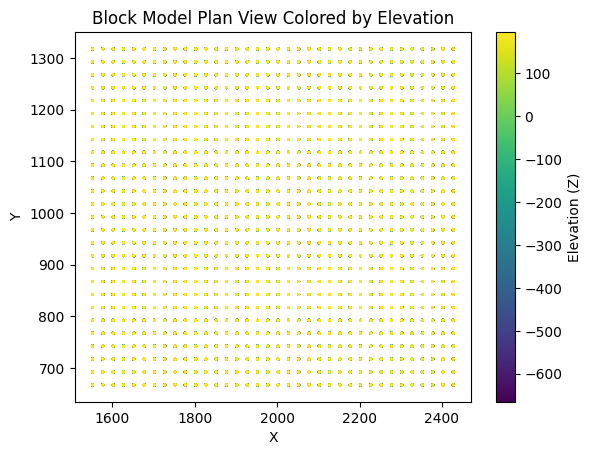

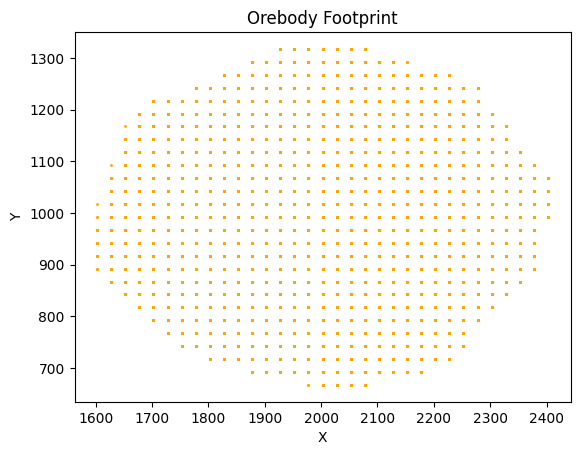

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the block model
df = pd.read_parquet('../data/synthetic_block_model.parquet')

# Check block spacing
print("X spacing:", df['x'].diff().value_counts())
print("Y spacing:", df['y'].diff().value_counts())
print("Z spacing:", df['z'].diff().value_counts())

# Scatter plot
plt.scatter(df['x'], df['y'], c=df['z'], cmap='viridis', s=1)
plt.colorbar(label='Elevation (Z)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Block Model Plan View Colored by Elevation')
plt.show()

# Orebody footprint
ore_blocks = df[df['zone_code'] > 0]
plt.scatter(ore_blocks['x'], ore_blocks['y'], c='orange', s=1)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Orebody Footprint')
plt.show()
